# Medium Small Cross Net VisualTCAV analysis

In [1]:
import sys, os, csv
import numpy as np
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

PROJECT_ROOT = Path(os.path.abspath(''))
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from model.model_dylan import FlexibleTNet
from VisualTCAV_pytorch import Model, LocalVisualTCAV, GlobalVisualTCAV


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {DEVICE}')

METHOD_CAV = "classifier"
CONCEPTS = ['circle_full', 'cross_full', 'square_full', 'circle_half_top', 'square_corner_bl', 'cross_arm_right']
LAYERS = []

/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/dlc/VisualTCAV
Device: cuda


In [2]:
STAGES = [
    {"conv": [8], "fc": [32], "name": "Stage 1"},
    {"conv": [16, 32], "fc": [64], "name": "Stage 2"},
    {"conv": [16, 32, 64], "fc": [128, 64], "name": "Stage 3"},
    {"conv": [25, 35, 50], "fc": [256, 128], "name": "Stage 4"},
    {"conv": [25, 35, 50, 75], "fc": [500, 250], "name": "Stage 5"},
    {"conv": [25, 35, 50, 75, 125], "fc": [500, 250, 50], "name": "Stage 6"},
]

def find_matching_stage(state_dict):
    conv_indices = set()
    for key in state_dict.keys():
        if "conv_layers" in key:
            parts = key.split('.')
            conv_indices.add(int(parts[1]))
    num_conv_layers = len(conv_indices)

    fc0_weight = state_dict.get("fc_layers.0.0.weight")
    in_features = fc0_weight.shape[1] if fc0_weight is not None else None

    for stage in STAGES:
        if len(stage["conv"]) == num_conv_layers:
            last_conv_key = f"conv_layers.{num_conv_layers-1}.0.weight"
            if state_dict[last_conv_key].shape[0] == stage["conv"][-1]:
                return stage
                
    raise ValueError("Could not find a matching stage configuration for this weight file.")

def load_flexible_model(weight_path, device='cpu'):
    state_dict = torch.load(weight_path, map_location=device, weights_only=True)
    config = find_matching_stage(state_dict)
    print(f"-> Detected: {config['name']}")

    model = FlexibleTNet(
        num_channels=1,
        num_classes=1,
        conv_channels=config["conv"],
        fc_layers=config["fc"],
        size_img=128,
        do_sigmoid=True
    )

    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model

weights_dir = 'weights_cross/'
filename = 'cross_medium_small.pth'

path = os.path.join(weights_dir, filename)

nn_model = load_flexible_model(path)


-> Detected: Stage 3


In [3]:

def preprocess_grayscale(imgs):
    return imgs.astype(np.float32) / 255.0

vtcav_model = Model(
    model_name='FlexNet_CrossMediumSmall',
    graph_path_filename=nn_model,           
    label_path_filename=['Cross present', 'Cross absent'],  
    preprocessing_function=preprocess_grayscale,
    binary_classification=True,
    max_examples=500,
    image_shape=[128, 128, 1],              
)


print(f'Model: {vtcav_model.model_name}')
print(f'Image shape: {vtcav_model.image_shape}')
print(f'Binary: {vtcav_model.binary_classification}')

Model: FlexNet_CrossMediumSmall
Image shape: [128, 128, 1]
Binary: True


In [4]:
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
TEST_IMAGES_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val')

print(f'Concepts dir: {CONCEPTS_DIR}')
print(f'Test images dir: {TEST_IMAGES_DIR}')
print(f'Concept folders: {sorted(os.listdir(CONCEPTS_DIR))}')

Concepts dir: /home/dlc/VisualTCAV/data/concepts
Test images dir: /home/dlc/VisualTCAV/data/aixi_shape/val
Concept folders: ['.DS_Store', '__MACOSX', 'blue', 'blue.zip', 'braided', 'chequered', 'circle_full', 'circle_half_bottom', 'circle_half_left', 'circle_half_right', 'circle_half_top', 'circle_quarter_bl', 'circle_quarter_br', 'circle_quarter_tl', 'circle_quarter_tr', 'cross_arm_bottom', 'cross_arm_horizontal', 'cross_arm_left', 'cross_arm_right', 'cross_arm_top', 'cross_arm_vertical', 'cross_full', 'dotted', 'forest_floor', 'forest_floor.zip', 'frekeled', 'random_0', 'random_1', 'random_2', 'random_3', 'random_pool', 'random_pool_2', 'random_pool_3', 'random_pool_4', 'spiralled', 'square_corner_bl', 'square_corner_br', 'square_corner_tl', 'square_corner_tr', 'square_edge_bottom', 'square_edge_left', 'square_edge_right', 'square_edge_top', 'square_full', 'square_half_bottom', 'square_half_left', 'square_half_right', 'square_half_top', 'stripped']


Loaded metadata for indices: 34 and 17


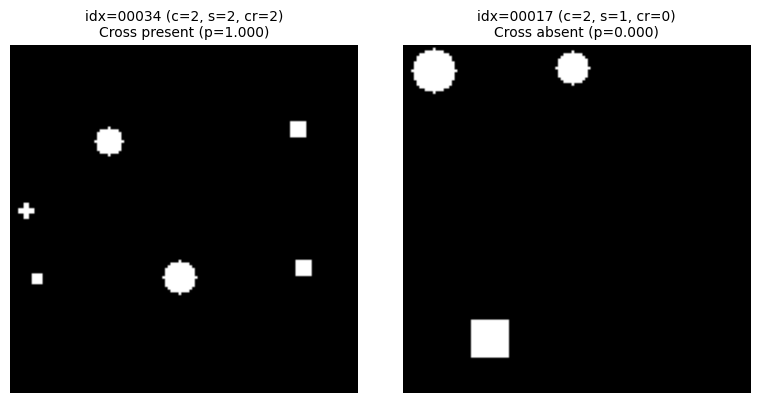

Image 1: 00034.png
Image 2: 00017.png


In [5]:


TARGET_IDX_WITH = 34   
TARGET_IDX_WITHOUT = 17 

val_csv = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val' / 'dades.csv'
val_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val'

with open(val_csv) as f:
    rows = list(csv.DictReader(f, delimiter=';'))


def get_metadata_for_idx(target_idx, csv_rows):
    for r in csv_rows:
        if int(r['']) == target_idx:
            return (target_idx, int(r['c']), int(r['s']), int(r['cr']))
    raise ValueError(f"Index {target_idx} not found in CSV.")


img_with = get_metadata_for_idx(TARGET_IDX_WITH, rows)
img_without = get_metadata_for_idx(TARGET_IDX_WITHOUT, rows)

print(f"Loaded metadata for indices: {img_with[0]} and {img_without[0]}")


img_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

nn_model.to(DEVICE)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, (idx, c, s, cr) in zip(axes, [img_with, img_without]):
    img = Image.open(val_dir / f'{idx:05d}.png')
    
    t = img_transform(img.convert('L')).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        p = nn_model(t).item()
        
    ax.imshow(np.array(img), cmap='gray')
    label = 'Cross present' if p > 0.5 else 'Cross absent'
    ax.set_title(f'idx={idx:05d} (c={c}, s={s}, cr={cr})\n{label} (p={p:.3f})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Image 1: {img_with[0]:05d}.png')
print(f'Image 2: {img_without[0]:05d}.png')

TCAV device: cuda
Circle present: torch.Size([261, 1, 128, 128])
Circle absent:  torch.Size([335, 1, 128, 128])

[1] Running TCAV: circle_full vs randoms...


/home/dlc/VisualTCAV/.venv/lib/python3.13/site-packages/captum/_utils/models/linear_model/train.py:409: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  bias_values = torch.FloatTensor([sklearn_model.intercept_]).to(  # type: ignore


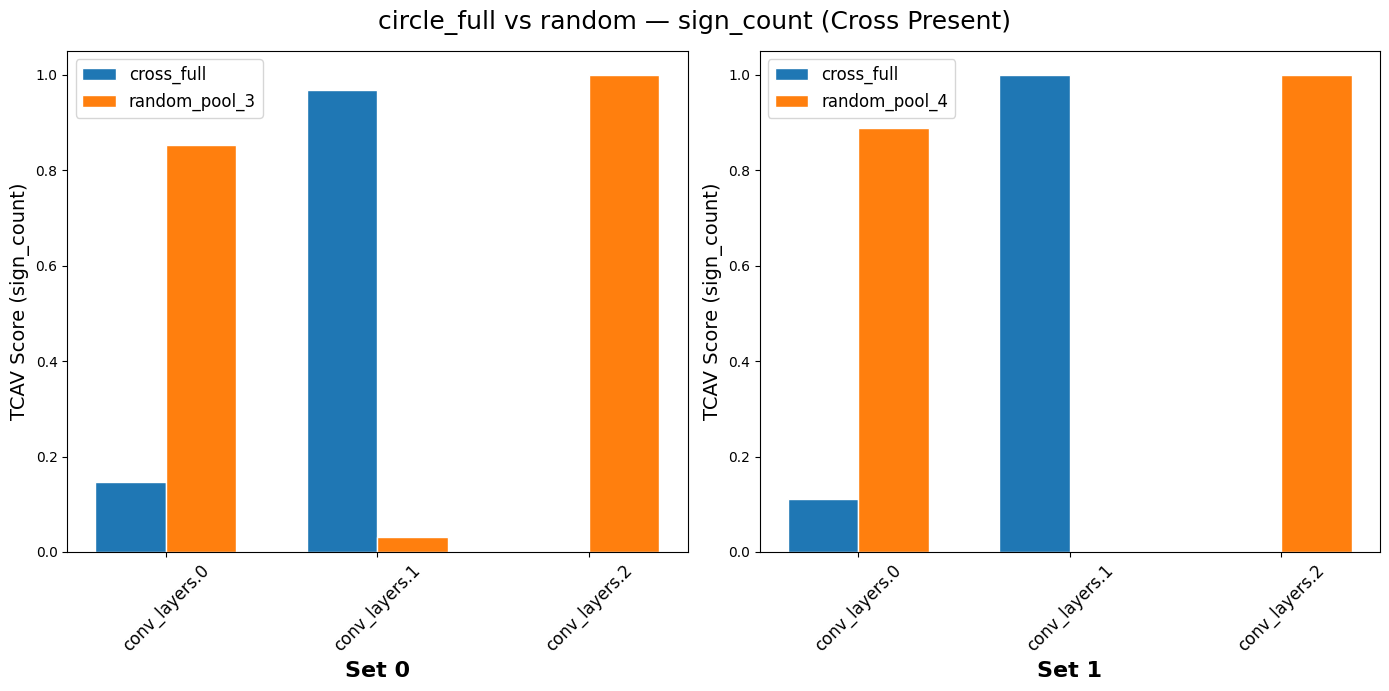

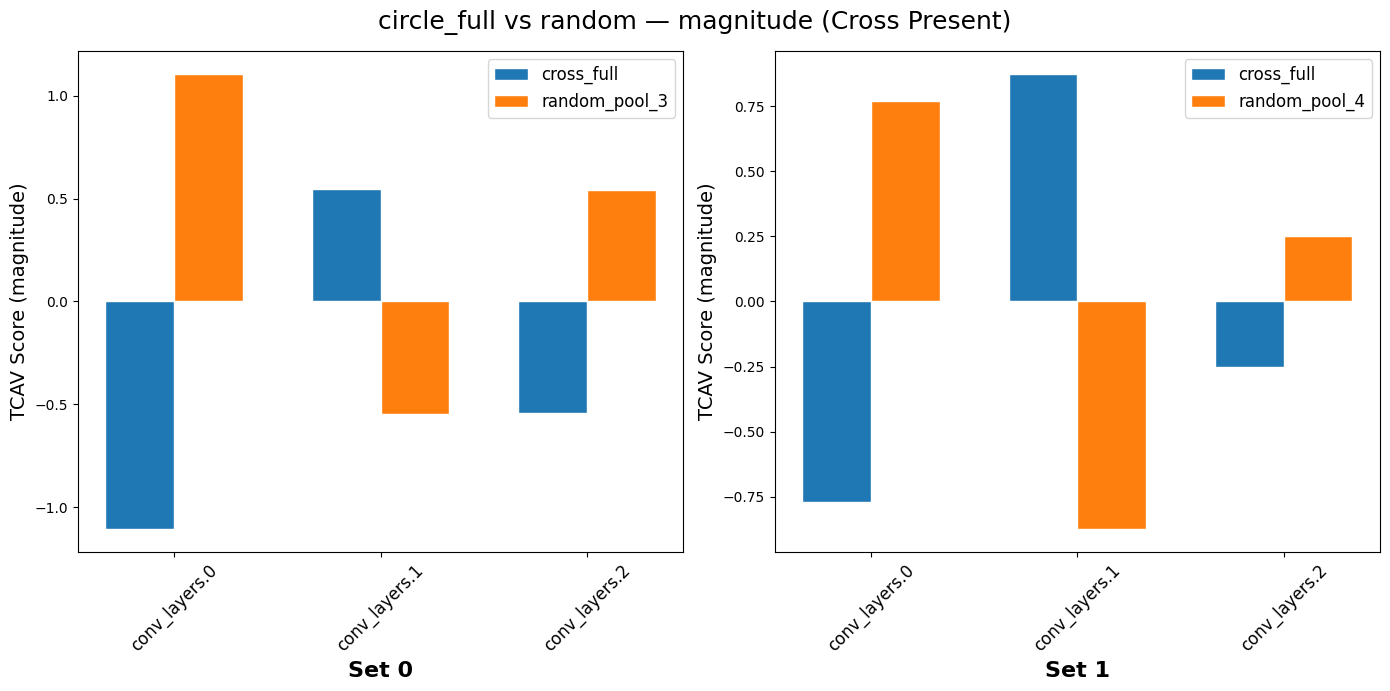


[2] Running TCAV: all concepts (Cross Present)...


In [ ]:
##############################################
# Captum TCAV — Circle Detection Model
##############################################
#
# ┌─────────────────────────────────────────────────────────────────┐
# │ PRE-SIGMOID LOGIT APPROACH (faithful to Kim et al. 2018)       │
# │                                                                 │
# │ TCAV computes: S_C(x) = ∇_h f_k(x) · v_C                     │
# │ The directional derivative of the model output w.r.t. layer    │
# │ activations, dotted with the Concept Activation Vector.        │
# │                                                                 │
# │ Kim et al. use pre-softmax logits (not probabilities) so the   │
# │ gradient doesn't suffer from output saturation. We follow the  │
# │ same approach: the wrapper outputs pre-sigmoid logits as a     │
# │ 2-column tensor [-z, z], avoiding sigmoid saturation entirely. │
# │                                                                 │
# │ This means we use Captum's default LayerGradientXActivation    │
# │ (plain gradients), NOT LayerIntegratedGradients.               │
# │                                                                 │
# │ Additionally, Captum's DefaultClassifier has a device mismatch │
# │ bug on GPU (classes() returns CPU tensor, argmax returns CUDA).│
# │ We fix this with GPUClassifier below.                          │
# └─────────────────────────────────────────────────────────────────┘

import gc
import glob
import random
import numpy as np
import os
import copy
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
from torchvision import transforms
from scipy.stats import ttest_ind

from captum.concept import TCAV, Concept
from captum.concept._utils.data_iterator import dataset_to_dataloader, CustomIterableDataset
from captum.concept._utils.common import concepts_to_str
from captum.concept._utils.classifier import Classifier
from captum._utils.models.linear_model.model import SkLearnSGDClassifier

# ── GPU-safe classifier (fixes Captum's device mismatch bug) ─────────
# Captum's DefaultClassifier crashes on GPU because:
#   1. self.lm.classes() returns a CPU tensor
#   2. torch.argmax(predict, dim=1) returns a CUDA tensor
#   3. CPU tensor indexed by CUDA tensor → RuntimeError
# This classifier keeps everything on the same device.

class GPUClassifier(Classifier):
    def __init__(self):
        self.lm = SkLearnSGDClassifier(alpha=0.01, max_iter=1000, tol=1e-3)

    def train_and_eval(self, dataloader, test_split_ratio=0.33, **kwargs):
        inputs = []
        labels = []
        for inp, label in dataloader:
            inputs.append(inp)
            labels.append(label)

        all_inputs = torch.cat(inputs)
        all_labels = torch.cat(labels)
        device = all_inputs.device

        # Shuffle and split
        z_list = list(zip(all_inputs, all_labels))
        random.shuffle(z_list)
        test_size = int(test_split_ratio * len(z_list))
        z_test, z_train = z_list[:test_size], z_list[test_size:]
        x_test, y_test = zip(*z_test)
        x_train, y_train = zip(*z_train)
        x_train, x_test = torch.stack(x_train), torch.stack(x_test)
        y_train, y_test = torch.stack(y_train), torch.stack(y_test)

        self.lm.device = device
        self.lm.fit(DataLoader(TensorDataset(x_train, y_train)))

        predict = self.lm(x_test)
        # FIX: move classes() to the same device as argmax output
        classes = self.lm.classes().to(device)
        predict = classes[torch.argmax(predict, dim=1)]
        score = predict.long() == y_test.long()

        return {"accs": score.float().mean()}

    def weights(self):
        weights = self.lm.representation()
        if weights.shape[0] == 1:
            return torch.stack([-1 * weights[0], weights[0]])
        return weights

    def classes(self):
        return self.lm.classes().detach().numpy()

# ── 1. Setup ─────────────────────────────────────────────────────────

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CONCEPTS_DIR = str(PROJECT_ROOT / 'data' / 'concepts')
GLOBAL_TEST_DIR = str(PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test')
CIRCLE_PRESENT_IDX = 1
CIRCLE_ABSENT_IDX = 0
print(f"TCAV device: {DEVICE}")

grayscale_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# ── 2. Pre-sigmoid logit wrapper ─────────────────────────────────────
# Captum TCAV expects [B, num_classes] output. Following Kim et al.,
# we output PRE-SIGMOID logits (not probabilities) to avoid sigmoid
# saturation killing gradients. Output: [-z, z] where z is the raw logit.

class LogitWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self._inner = model
        self.conv_layers = model.conv_layers
        self.fc_layers = model.fc_layers
        self.output = model.output

    def forward(self, x):
        x = x.to(next(self._inner.parameters()).device)
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        z = self.output(x)  # raw logit, NO sigmoid
        return torch.cat([-z, z], dim=1)

tcav_model = LogitWrapper(copy.deepcopy(nn_model).to(DEVICE))
tcav_model.eval()

# ── 3. Helpers ───────────────────────────────────────────────────────

def get_tensor_from_filename(filename):
    img = Image.open(filename).convert('L')
    return grayscale_transform(img)

MAX_CONCEPT_IMAGES = 250  # Kim et al. used as few as 30; reduce further if OOM

class LimitedIterableDataset(torch.utils.data.IterableDataset):
    """Like CustomIterableDataset but limits to max_images files."""
    def __init__(self, transform_fn, path, max_images):
        self.transform_fn = transform_fn
        all_files = sorted(glob.glob(os.path.join(path, '*')))
        if max_images and len(all_files) > max_images:
            random.seed(42)
            all_files = random.sample(all_files, max_images)
        self.files = all_files

    def __iter__(self):
        for f in self.files:
            yield self.transform_fn(f)

def assemble_concept(name, id, concepts_path=CONCEPTS_DIR, max_images=MAX_CONCEPT_IMAGES):
    concept_path = os.path.join(concepts_path, name) + "/"
    if max_images:
        dataset = LimitedIterableDataset(get_tensor_from_filename, concept_path, max_images)
    else:
        dataset = CustomIterableDataset(get_tensor_from_filename, concept_path)
    concept_iter = dataset_to_dataloader(dataset)
    return Concept(id=id, name=name, data_iter=concept_iter)

def load_test_images(class_dir):
    tensors = []
    for f in sorted(glob.glob(os.path.join(class_dir, '*.png'))):
        tensors.append(get_tensor_from_filename(f))
    return torch.stack(tensors)

def format_float(f):
    return float('{:.3f}'.format(f) if abs(f) >= 0.0005 else '{:.3e}'.format(f))

def plot_tcav_scores(experimental_sets, tcav_scores, layers, title, metric='sign_count'):
    n_sets = len(experimental_sets)
    fig, ax = plt.subplots(1, n_sets, figsize=(7 * n_sets, 7))
    if n_sets == 1:
        ax = [ax]

    for idx_es, concepts in enumerate(experimental_sets):
        concepts_key = concepts_to_str(concepts)
        n_concepts = len(concepts)
        barWidth = 1 / (n_concepts + 1)

        pos = [np.arange(len(layers))]
        for i in range(1, n_concepts):
            pos.append([(x + barWidth) for x in pos[i-1]])

        for i in range(n_concepts):
            val = [format_float(scores[metric][i])
                   for _, scores in tcav_scores[concepts_key].items()]
            ax[idx_es].bar(pos[i], val, width=barWidth, edgecolor='white',
                           label=concepts[i].name)

        ax[idx_es].set_xlabel(f'Set {idx_es}', fontweight='bold', fontsize=16)
        ax[idx_es].set_xticks([r + barWidth * (n_concepts - 1) / 2 for r in range(len(layers))])
        ax[idx_es].set_xticklabels(layers, fontsize=12, rotation=45)
        ax[idx_es].legend(fontsize=12)
        if metric == 'sign_count':
            ax[idx_es].set_ylim([0, 1.05])
        ax[idx_es].set_ylabel(f'TCAV Score ({metric})', fontsize=14)

    plt.suptitle(title, fontsize=18)
    plt.tight_layout()
    plt.show()

# ── 4. Concepts ──────────────────────────────────────────────────────

circle_full   = assemble_concept("circle_full",      0)
cross_full    = assemble_concept("cross_full",        1)
square_full   = assemble_concept("square_full",       2)
circle_half   = assemble_concept("circle_half_top",   3)
square_corner = assemble_concept("square_corner_bl",  4)
cross_arm     = assemble_concept("cross_arm_right",   5)

random_0 = assemble_concept("random_0", 10)
random_1 = assemble_concept("random_1", 11)
random_2 = assemble_concept("random_pool_3", 12)
random_3 = assemble_concept("random_pool_4", 13)

# ── 5. Layers & TCAV instance ────────────────────────────────────────

layers = ['conv_layers.0', 'conv_layers.1', 'conv_layers.2']

mytcav = TCAV(
    model=tcav_model,
    layers=layers,
    model_id = "Cross_MediumSmall", 
    classifier=GPUClassifier(),
)

# ── 6. Load test images ──────────────────────────────────────────────

circle_present_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'cross_present')).to(DEVICE)
circle_absent_tensors = load_test_images(os.path.join(GLOBAL_TEST_DIR, 'cross_absent')).to(DEVICE)
print(f"Circle present: {circle_present_tensors.shape}")
print(f"Circle absent:  {circle_absent_tensors.shape}")

# ── 7. Experimental sets ─────────────────────────────────────────────

experimental_sets_rand = [
    [cross_full, random_2],
    [cross_full, random_3],
]

experimental_sets_all = [
    [circle_full, cross_full, square_full, circle_half, square_corner, cross_arm],
]

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: circle_full vs randoms
# ══════════════════════════════════════════════════════════════════════

print("\n[1] Running TCAV: circle_full vs randoms...")
scores_rand = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_rand,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — sign_count (Cross Present)')
plot_tcav_scores(experimental_sets_rand, scores_rand, layers,
                 title='circle_full vs random — magnitude (Cross Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: All concepts head-to-head (Circle Present)
# ══════════════════════════════════════════════════════════════════════

print("\n[2] Running TCAV: all concepts (Cross Present)...")
scores_all_present = mytcav.interpret(
    inputs=circle_present_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_PRESENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — sign_count (Cross Present)')
plot_tcav_scores(experimental_sets_all, scores_all_present, layers,
                 title='All Concepts — magnitude (Cross Present)',
                 metric='magnitude')

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENT 3: All concepts head-to-head (Circle Absent)
# ══════════════════════════════════════════════════════════════════════

print("\n[3] Running TCAV: all concepts (Cross Absent)...")
scores_all_absent = mytcav.interpret(
    inputs=circle_absent_tensors,
    experimental_sets=experimental_sets_all,
    target=CIRCLE_ABSENT_IDX,
)

plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — sign_count (Cross Absent)')
plot_tcav_scores(experimental_sets_all, scores_all_absent, layers,
                 title='All Concepts — magnitude (Cross Absent)',
                 metric='magnitude')

# Free experiments 1-3
del scores_rand, scores_all_present, scores_all_absent
gc.collect()


## Amb Cercles

In [6]:
local_explainer = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4', # Same distribution idk
    cav_method=METHOD_CAV,
    device=DEVICE,
)

local_explainer.setConcepts(CONCEPTS)
local_explainer.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

predictions = local_explainer.predict(no_sort=True)
predictions.info()

print(f'\nAvailable layers: {vtcav_model.getLayerNames()}')


Model: FlexNet_CrossMediumSmall
    Image    Class name Confidence
00034.png Cross present       1.00

Available layers: ['conv_layers', 'conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0', 'fc_layers', 'fc_layers.0', 'fc_layers.0.0', 'fc_layers.1', 'fc_layers.1.0', 'output']


```
  FlexibleTNet                                                                                                                                               
  ├── conv_layers          → Sequential (the whole conv block container)                                                                                     
  │   └── 0                → Sequential (first conv block: Conv2d + ReLU + BN + MaxPool)                                                                     
  │       ├── 0            → Conv2d(1, 8, 3x3)        ← conv_layers.0.0                                                                                      
  │       ├── 1            → ReLU()
  │       ├── 2            → BatchNorm2d(8)
  │       └── 3            → MaxPool2d(2)
  ├── fc_layers            → Sequential (the whole FC block container)
  │   └── 0                → Sequential (first FC block: Linear + Dropout + ReLU)
  │       ├── 0            → Linear(32768 → 32)        ← fc_layers.0.0
  │       ├── 1            → Dropout(0.2)
  │       └── 2            → ReLU()
  ├── output               → Linear(32 → 1)
  └── final_act            → Sigmoid()
  ```
  

In [7]:
local_explainer.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer.concepts:
    for layer_name in local_explainer.layers:
        cl = local_explainer.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

Layers: 100%|██████████| 3/3 [00:02<00:00,  1.22it/s]

circle_full @ conv_layers.0: {0: 0.28849107027053833, 1: 0.04068339616060257}
circle_full @ conv_layers.1: {0: 0.050477512180805206, 1: 0.01483641006052494}
circle_full @ conv_layers.2: {0: 0.001979915192350745, 1: 0.00016473661526106298}
cross_full @ conv_layers.0: {0: 0.1217213124036789, 1: 0.021525299176573753}
cross_full @ conv_layers.1: {0: 0.08950814604759216, 1: 0.010689567774534225}
cross_full @ conv_layers.2: {0: 0.04154220223426819, 1: 0.018623821437358856}
square_full @ conv_layers.0: {0: 0.18451854586601257, 1: 0.038999445736408234}
square_full @ conv_layers.1: {0: 0.050552111119031906, 1: 0.011443075723946095}
square_full @ conv_layers.2: {0: 0.001556133502162993, 1: 7.676972745684907e-05}
circle_half_top @ conv_layers.0: {0: 0.27110376954078674, 1: 0.03213689848780632}
circle_half_top @ conv_layers.1: {0: 0.020361624658107758, 1: 0.008506004698574543}
circle_half_top @ conv_layers.2: {0: 0.002273722318932414, 1: 0.0001164175191661343}
square_corner_bl @ conv_layers.0: {0:

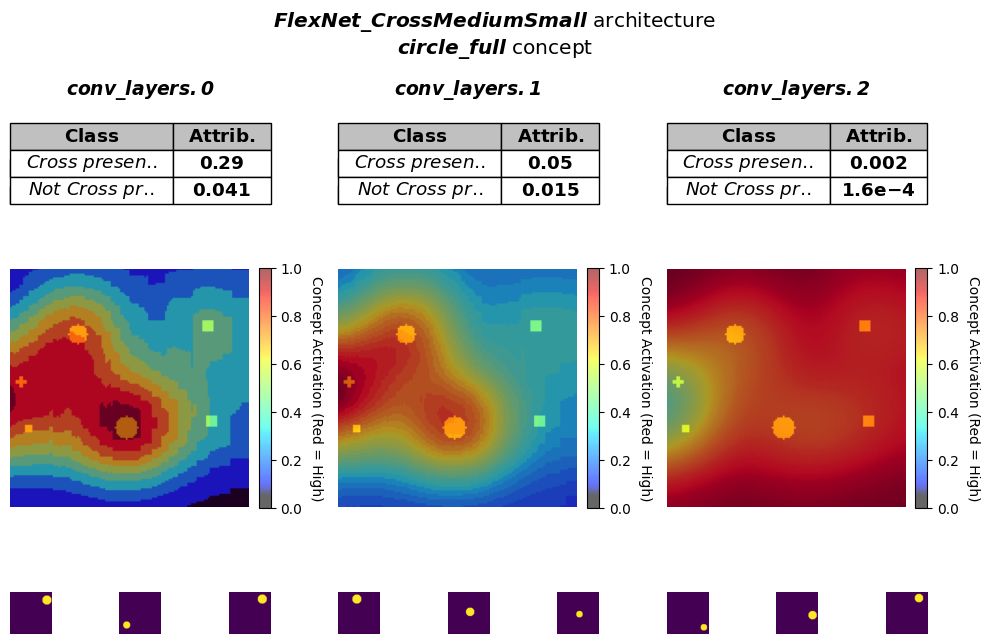

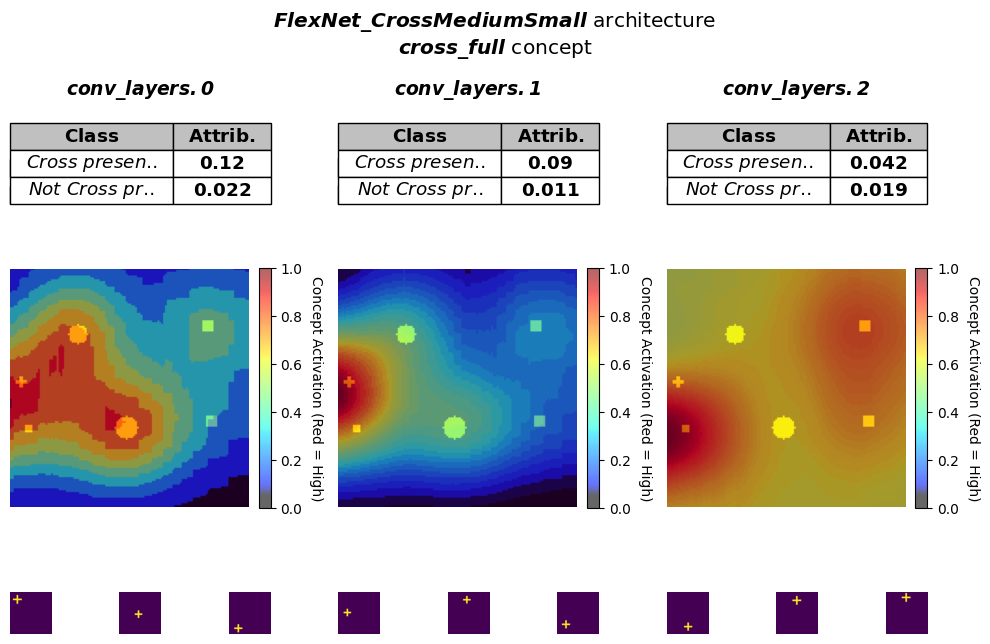

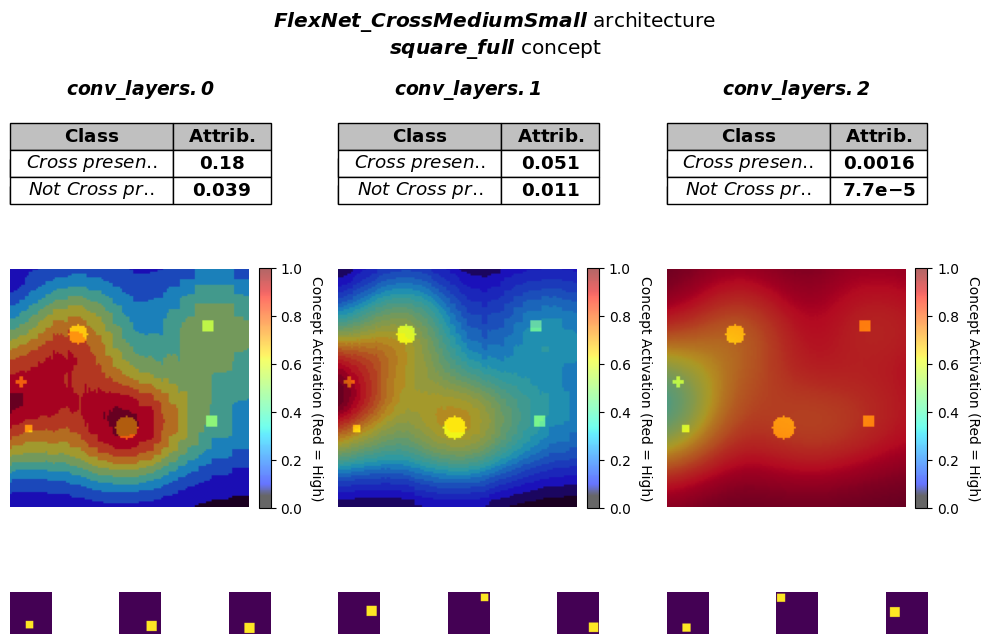

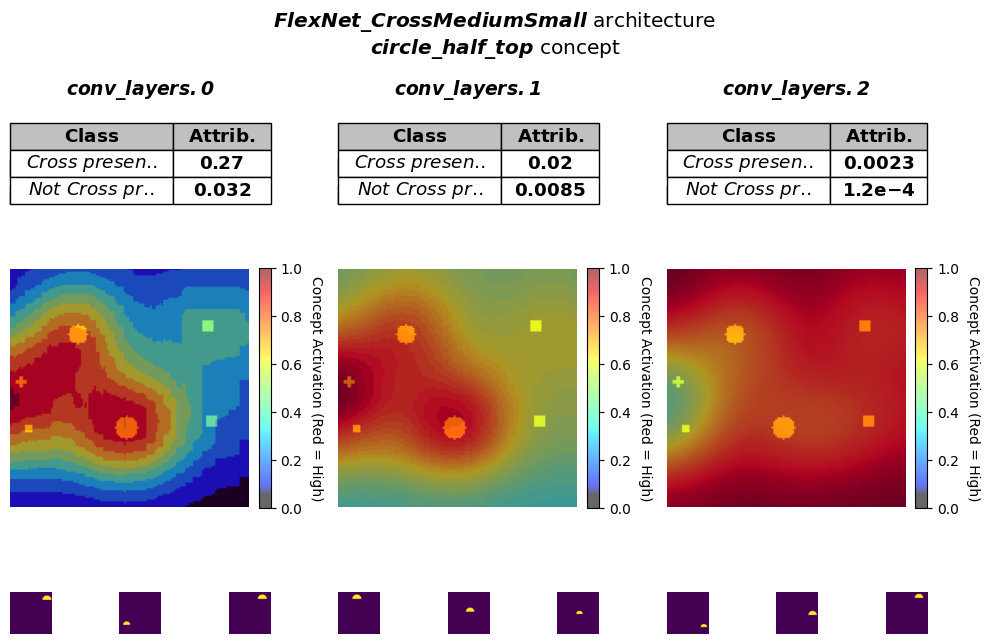

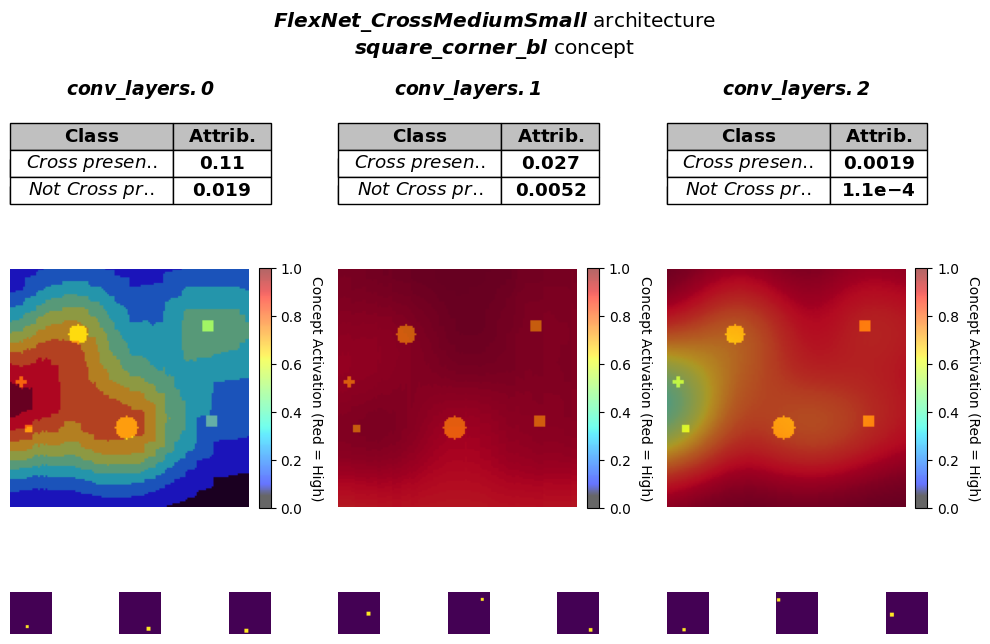

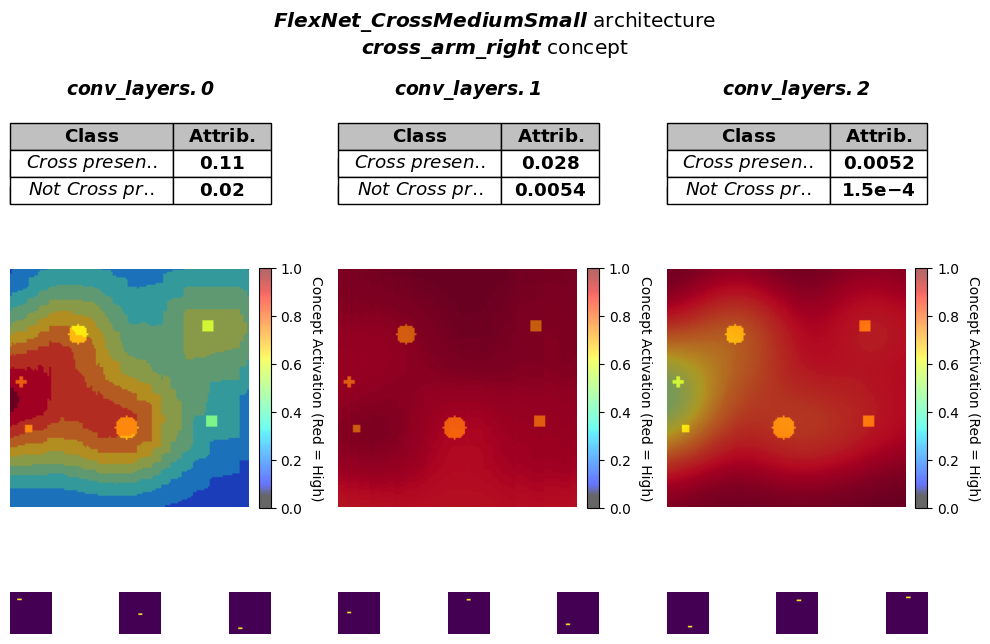

In [8]:
# Plot heatmaps
local_explainer.plot()

circle_full: norm=1.5919, emblem=(13.9549, 3.2848)
cross_full: norm=1.3116, emblem=(4.6535, 1.9230)
square_full: norm=1.7450, emblem=(8.0373, 4.0038)
circle_half_top: norm=1.3770, emblem=(4.4481, 1.5578)
square_corner_bl: norm=1.2716, emblem=(1.1180, 0.4458)
cross_arm_right: norm=1.2375, emblem=(0.9428, 0.2385)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8926
  circle_full vs square_full: 0.9686
  circle_full vs circle_half_top: 0.9413
  circle_full vs square_corner_bl: 0.7940
  circle_full vs cross_arm_right: 0.7748
  cross_full vs square_full: 0.8839
  cross_full vs circle_half_top: 0.9725
  cross_full vs square_corner_bl: 0.9649
  cross_full vs cross_arm_right: 0.9553
  square_full vs circle_half_top: 0.9022
  square_full vs square_corner_bl: 0.7821
  square_full vs cross_arm_right: 0.7613
  circle_half_top vs square_corner_bl: 0.9375
  circle_half_top vs cross_arm_right: 0.9278
  square_corner_bl vs cross_arm_right: 0.9988


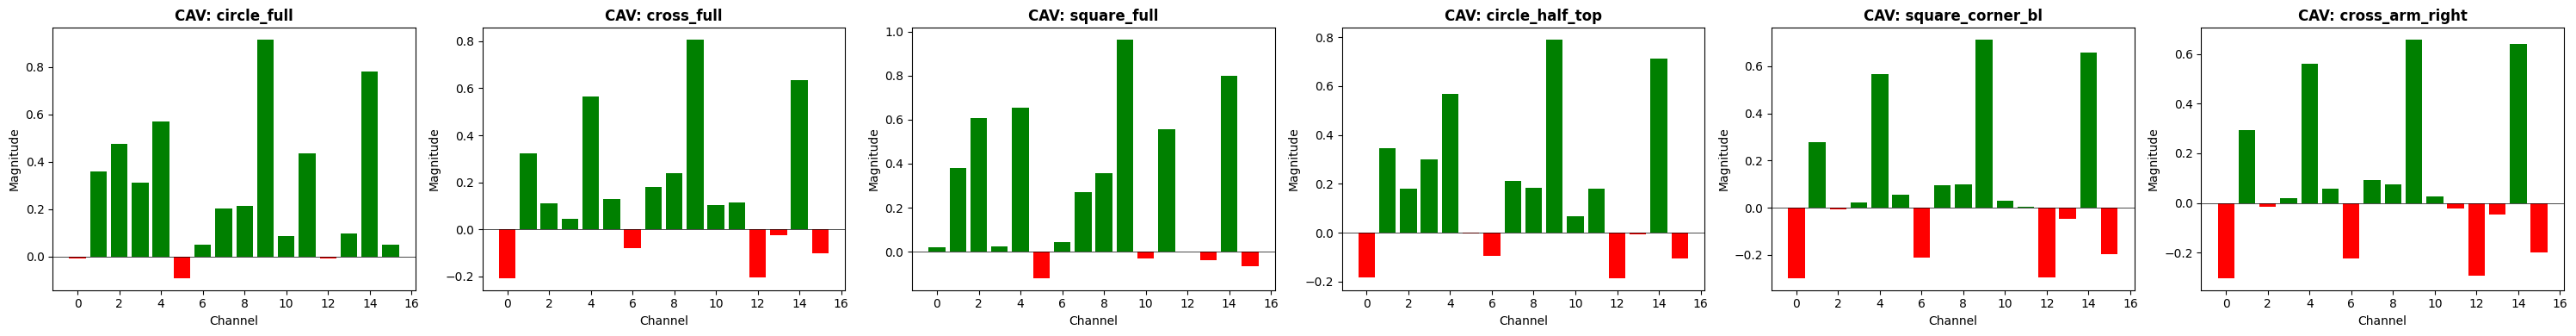

circle_full: norm=0.8274, emblem=(5.2371, 0.0000)
cross_full: norm=0.6890, emblem=(2.4986, 0.1943)
square_full: norm=0.9207, emblem=(2.5933, 0.8207)
circle_half_top: norm=0.6924, emblem=(1.8007, 0.0000)
square_corner_bl: norm=0.5288, emblem=(0.2630, 0.0000)
cross_arm_right: norm=0.5082, emblem=(0.2505, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.8010
  circle_full vs square_full: 0.7690
  circle_full vs circle_half_top: 0.9370
  circle_full vs square_corner_bl: 0.7412
  circle_full vs cross_arm_right: 0.7266
  cross_full vs square_full: 0.8494
  cross_full vs circle_half_top: 0.8904
  cross_full vs square_corner_bl: 0.9156
  cross_full vs cross_arm_right: 0.9018
  square_full vs circle_half_top: 0.8085
  square_full vs square_corner_bl: 0.7928
  square_full vs cross_arm_right: 0.7573
  circle_half_top vs square_corner_bl: 0.8789
  circle_half_top vs cross_arm_right: 0.8695
  square_corner_bl vs cross_arm_right: 0.9956


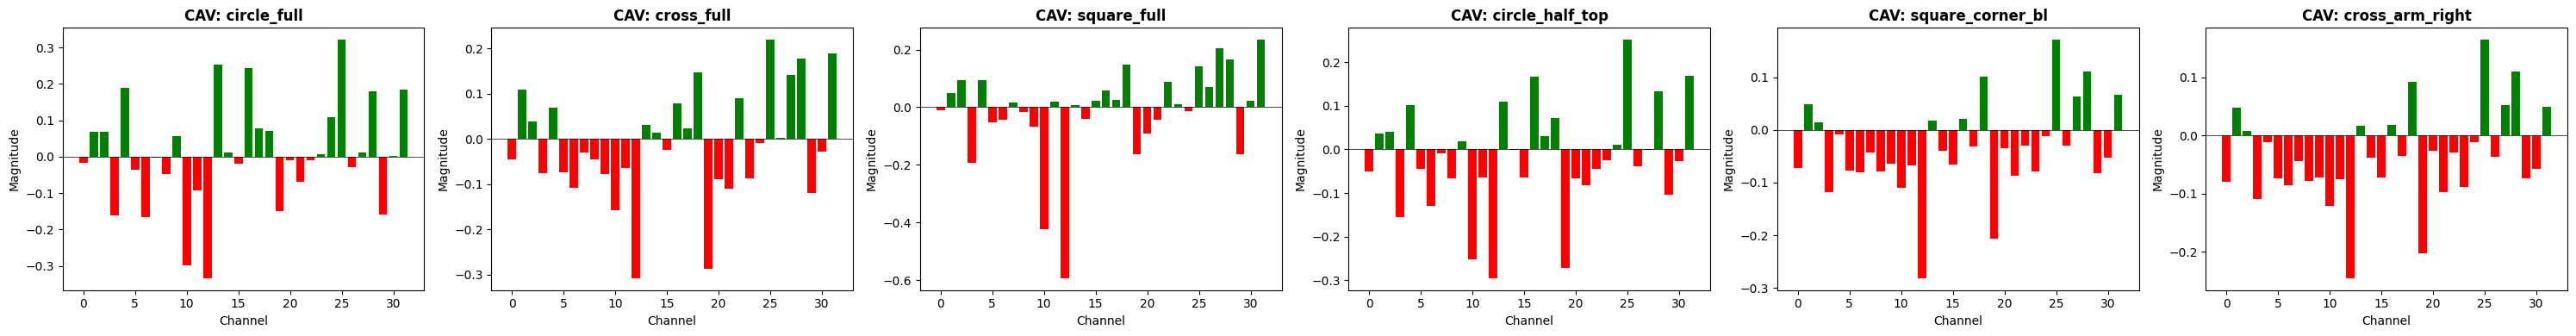

circle_full: norm=0.9009, emblem=(0.6771, 0.0000)
cross_full: norm=0.7758, emblem=(1.1856, 0.0000)
square_full: norm=0.9869, emblem=(0.6547, 0.0000)
circle_half_top: norm=0.8637, emblem=(0.6490, 0.0000)
square_corner_bl: norm=0.7437, emblem=(0.5374, 0.0000)
cross_arm_right: norm=0.7236, emblem=(0.4032, 0.0000)

Cosine similarities between CAV directions:
  circle_full vs cross_full: 0.5644
  circle_full vs square_full: 0.9126
  circle_full vs circle_half_top: 0.9884
  circle_full vs square_corner_bl: 0.9193
  circle_full vs cross_arm_right: 0.6752
  cross_full vs square_full: 0.5116
  cross_full vs circle_half_top: 0.6098
  cross_full vs square_corner_bl: 0.7572
  cross_full vs cross_arm_right: 0.8333
  square_full vs circle_half_top: 0.9235
  square_full vs square_corner_bl: 0.8559
  square_full vs cross_arm_right: 0.5077
  circle_half_top vs square_corner_bl: 0.9420
  circle_half_top vs cross_arm_right: 0.7005
  square_corner_bl vs cross_arm_right: 0.8593


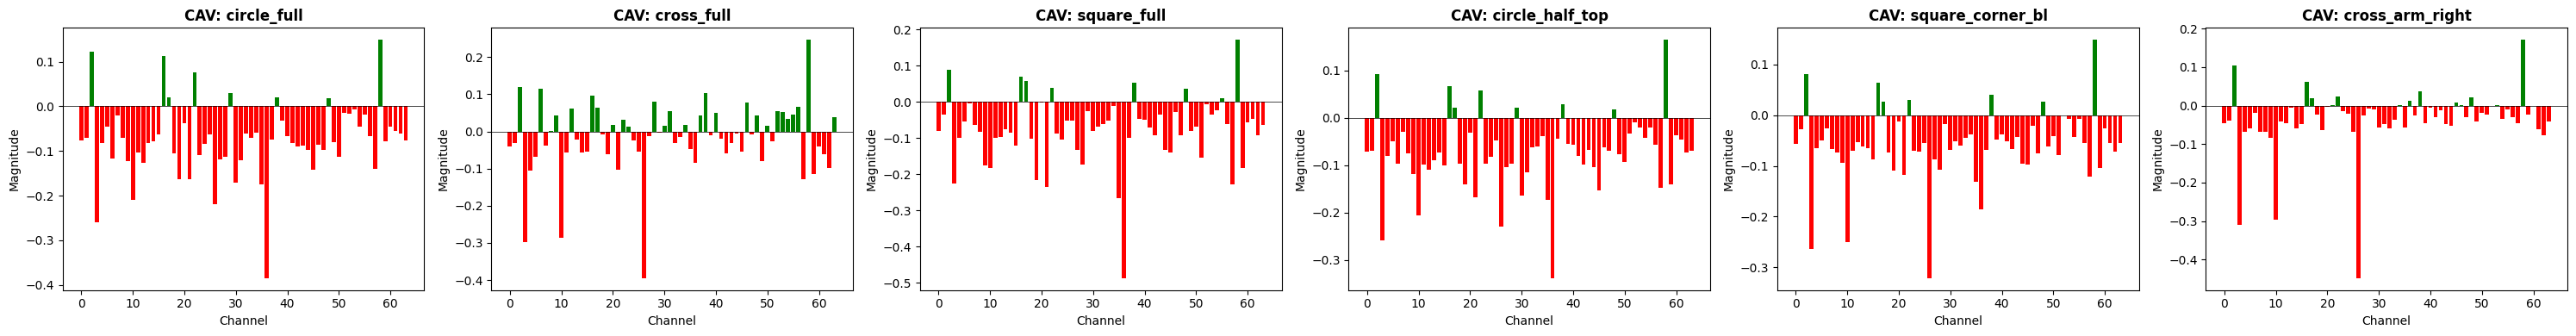

In [9]:
for x in [0, 1, 2]:
    concept_names = local_explainer.concepts
    layer_name = local_explainer.layers[x]

    
    cavs = {}
    for cn in concept_names:
        cav = local_explainer.getCAVs(layer_name, cn)
        cavs[cn] = cav.direction
        print(f'{cn}: norm={cav.direction.norm():.4f}, '
            f'emblem=({cav.concept_emblem[0]:.4f}, {cav.concept_emblem[1]:.4f})')

    
    print('\nCosine similarities between CAV directions:')
    for a, b in combinations(concept_names, 2):
        cos = F.cosine_similarity(
            cavs[a].unsqueeze(0), cavs[b].unsqueeze(0)
        ).item()
        print(f'  {a} vs {b}: {cos:.4f}')

    
    fig, axes = plt.subplots(1, len(concept_names), figsize=(5 * len(concept_names), 4))
    for ax, name in zip(axes, concept_names):
        d = cavs[name].cpu().numpy()
        ax.bar(range(len(d)), d, color=['green' if v > 0 else 'red' for v in d])
        ax.set_title(f'CAV: {name}', fontweight='bold')
        ax.set_xlabel('Channel')
        ax.set_ylabel('Magnitude')
        ax.axhline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## Sense Cercles


Model: FlexNet_CrossMediumSmall
    Image    Class name Confidence
00017.png Cross present       0.00


Layers: 100%|██████████| 3/3 [00:02<00:00,  1.33it/s]


circle_full @ conv_layers.0: {0: 0.090499646961689, 1: 0.20586350560188293}
circle_full @ conv_layers.1: {0: 0.04744186997413635, 1: 0.1761549711227417}
circle_full @ conv_layers.2: {0: 0.008536452427506447, 1: 0.010486684739589691}
cross_full @ conv_layers.0: {0: 0.07996262609958649, 1: 0.098953977227211}
cross_full @ conv_layers.1: {0: 0.09801845252513885, 1: 0.13123026490211487}
cross_full @ conv_layers.2: {0: 0.0051695057190954685, 1: 0.07394832372665405}
square_full @ conv_layers.0: {0: 0.10376179218292236, 1: 0.11742058396339417}
square_full @ conv_layers.1: {0: 0.04271863028407097, 1: 0.05537471920251846}
square_full @ conv_layers.2: {0: 0.0022075423039495945, 1: 0.01242150366306305}
circle_half_top @ conv_layers.0: {0: 0.0869102030992508, 1: 0.17767441272735596}
circle_half_top @ conv_layers.1: {0: 0.030724216252565384, 1: 0.08133704960346222}
circle_half_top @ conv_layers.2: {0: 0.004769949242472649, 1: 0.015431657433509827}
square_corner_bl @ conv_layers.0: {0: 0.058927446603

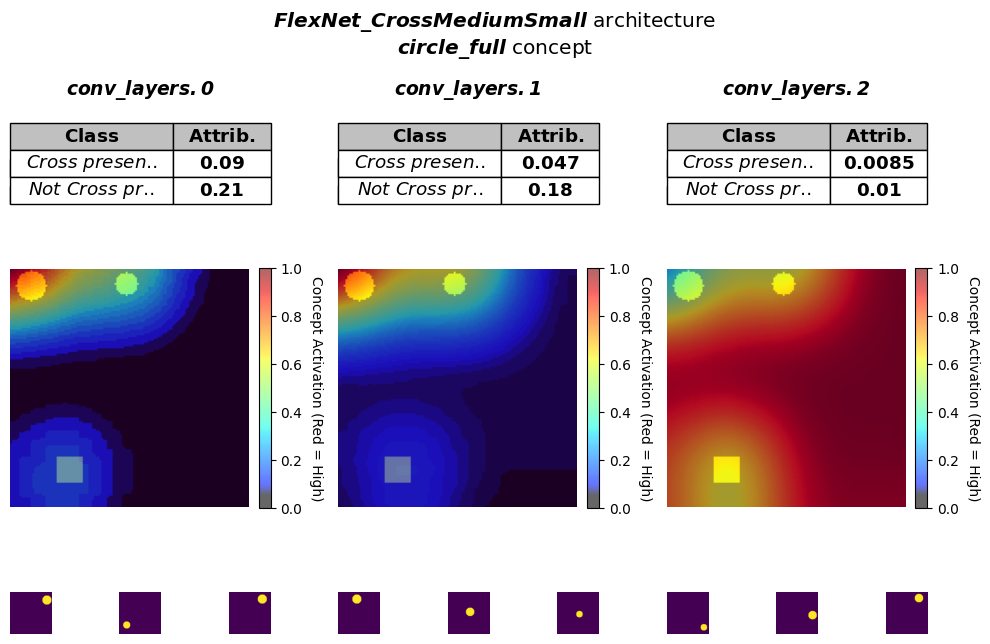

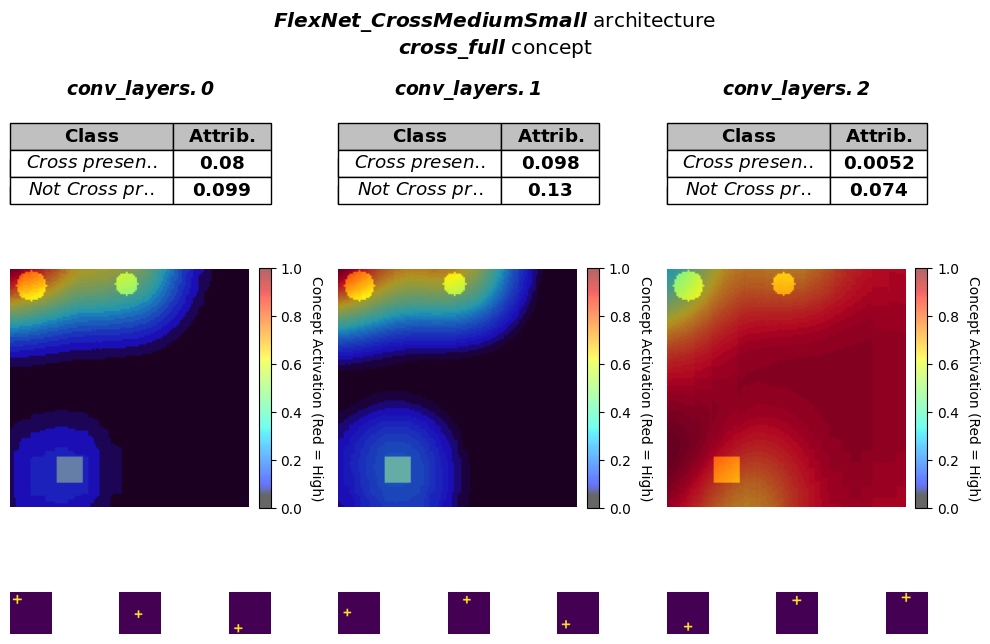

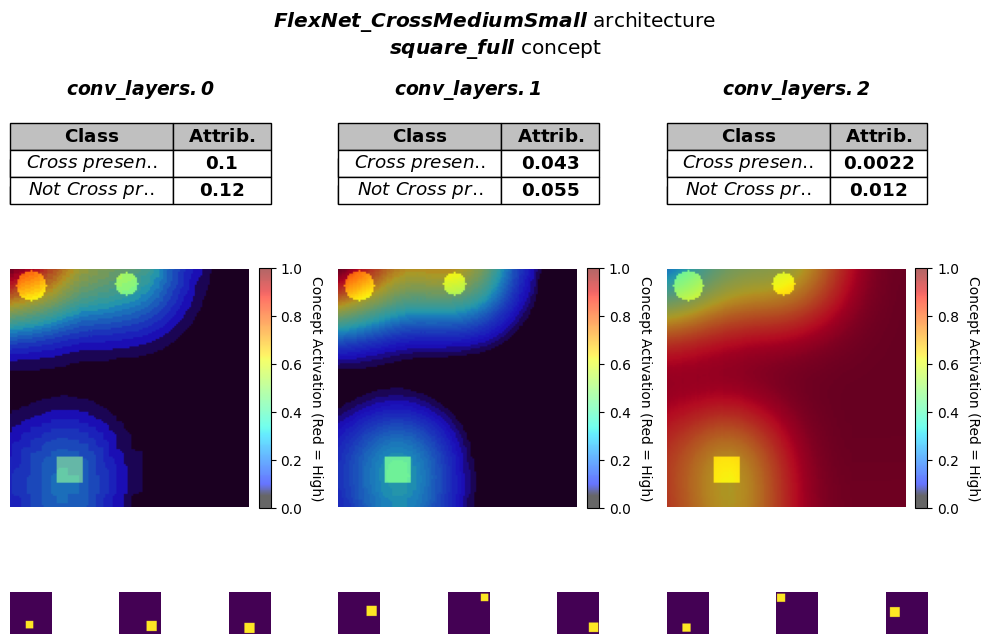

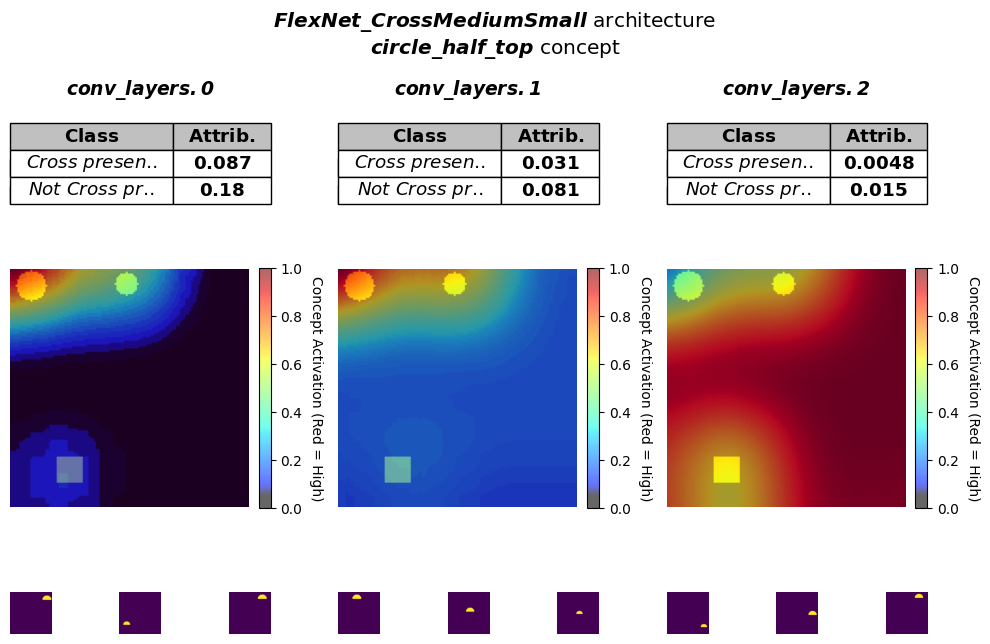

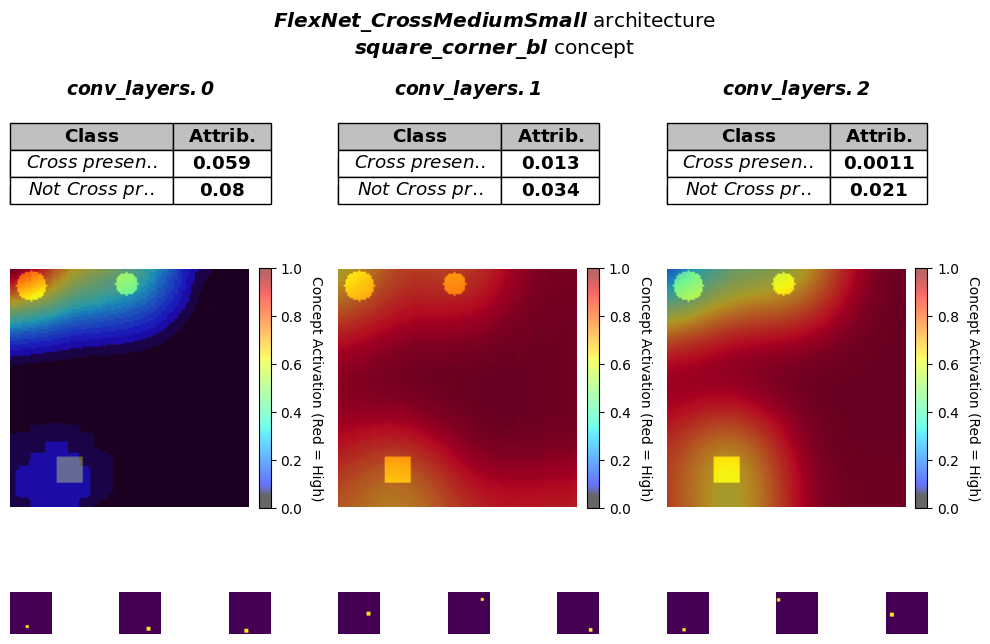

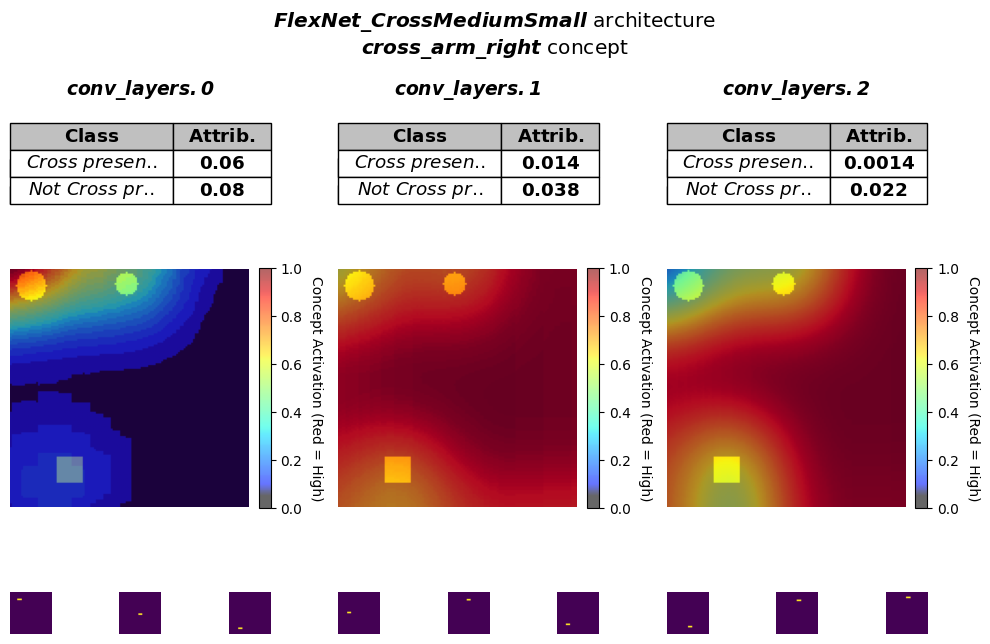

In [10]:
local_explainer2 = LocalVisualTCAV(
    test_image_filename=f'{img_without[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_explainer2.setConcepts(CONCEPTS)
local_explainer2.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

predictions2 = local_explainer2.predict(no_sort=True)
predictions2.info()

local_explainer2.explain(cache_cav=False, cache_random=False)

for concept_name in local_explainer2.concepts:
    for layer_name in local_explainer2.layers:
        cl = local_explainer2.computations[layer_name][concept_name]
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v
                   for k, v in cl.attributions.items()}
        print(f'{concept_name} @ {layer_name}: {attribs}')

local_explainer2.plot()

## Global Explanation

In [11]:
import shutil

# Select 200 images per grup as stated in the paper
cross_indices, no_cross_indices = [], []

for r in rows:
    idx, c = int(r['']), int(r['s'])
    if c > 0 and len(cross_indices) < 200:
        cross_indices.append(idx)
    elif c == 0 and len(no_cross_indices) < 200:
        no_cross_indices.append(idx)


global_test_dir = PROJECT_ROOT / 'data' / 'aixi_shape' / 'val_global_test'
for group_name, indices in [('cross_present', cross_indices), ('cross_absent', no_cross_indices)]:
    group_dir = global_test_dir / group_name
    group_dir.mkdir(parents=True, exist_ok=True)
    for idx in indices:
        src = val_dir / f'{idx:05d}.png'
        dst = group_dir / f'{idx:05d}.png'
        if not dst.exists():
            shutil.copy2(src, dst)

print(f'Square present: {len(cross_indices)} images')
print(f'Square absent:  {len(no_cross_indices)} images')
print(f'Test dir: {global_test_dir}')

Square present: 200 images
Square absent:  200 images
Test dir: /home/dlc/VisualTCAV/data/aixi_shape/val_global_test


In [12]:
global_circle = GlobalVisualTCAV(
    target_class='Cross present',
    test_images_folder='cross_present',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_circle.setConcepts(CONCEPTS)
global_circle.setLayers(['conv_layers.0', 'conv_layers.1', 'conv_layers.2'])

print('Running global explanation - Cross Present...')
global_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Cross Present...


Layers: 100%|██████████| 3/3 [00:13<00:00,  4.62s/it]


In [13]:
global_circle.statsInfo()


Model: FlexNet_CrossMediumSmall | Class: Cross present | Folder: cross_present
         Concept         Layer      Attrib. mean  Attrib. 95.45% CI
     circle_full conv_layers.0    0.255 ± 0.0784     [0.245, 0.265]
                 conv_layers.1   0.0414 ± 0.0436    [0.036, 0.0468]
                 conv_layers.2 0.00256 ± 0.00662 [0.00174, 0.00338]
      cross_full conv_layers.0    0.157 ± 0.0817     [0.147, 0.168]
                 conv_layers.1   0.0741 ± 0.0668   [0.0658, 0.0823]
                 conv_layers.2   0.0324 ± 0.0319   [0.0284, 0.0364]
     square_full conv_layers.0    0.191 ± 0.0921      [0.18, 0.203]
                 conv_layers.1   0.0463 ± 0.0542    [0.0396, 0.053]
                 conv_layers.2  0.0029 ± 0.00897 [0.00179, 0.00401]
 circle_half_top conv_layers.0    0.241 ± 0.0837     [0.231, 0.252]
                 conv_layers.1    0.0212 ± 0.023   [0.0184, 0.0241]
                 conv_layers.2 0.00303 ± 0.00792 [0.00205, 0.00401]
square_corner_bl conv_layers.0    0.

In [14]:
global_no_circle = GlobalVisualTCAV(
    target_class='Cross absent',  
    test_images_folder='cross_absent',
    m_steps=80,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=str(global_test_dir),
    random_images_folder='random_pool_4',
    cav_method=METHOD_CAV,
    device=DEVICE,
)

global_no_circle.setConcepts(CONCEPTS)
global_no_circle.setLayers(['conv_layers.0', 'conv_layers.1','conv_layers.2'])

print('Running global explanation - Cross Absent...')
global_no_circle.explain(cache_cav=False, cache_random=False)

Running global explanation - Cross Absent...


Layers: 100%|██████████| 3/3 [00:25<00:00,  8.63s/it]


In [15]:
global_no_circle.statsInfo()


Model: FlexNet_CrossMediumSmall | Class: Cross absent | Folder: cross_absent
         Concept         Layer     Attrib. mean Attrib. 95.45% CI
     circle_full conv_layers.0    0.181 ± 0.107    [0.169, 0.193]
                 conv_layers.1  0.0619 ± 0.0644  [0.0549, 0.0689]
                 conv_layers.2  0.0105 ± 0.0271 [0.00753, 0.0134]
      cross_full conv_layers.0   0.123 ± 0.0849    [0.114, 0.133]
                 conv_layers.1  0.0895 ± 0.0821  [0.0805, 0.0985]
                 conv_layers.2  0.0393 ± 0.0484   [0.034, 0.0446]
     square_full conv_layers.0   0.153 ± 0.0971    [0.142, 0.163]
                 conv_layers.1  0.0597 ± 0.0693  [0.0521, 0.0673]
                 conv_layers.2 0.00895 ± 0.0238 [0.00635, 0.0115]
 circle_half_top conv_layers.0    0.169 ± 0.107    [0.157, 0.181]
                 conv_layers.1  0.0391 ± 0.0431  [0.0343, 0.0438]
                 conv_layers.2  0.0117 ± 0.0321 [0.00818, 0.0152]
square_corner_bl conv_layers.0   0.103 ± 0.0787   [0.0939, 0.111

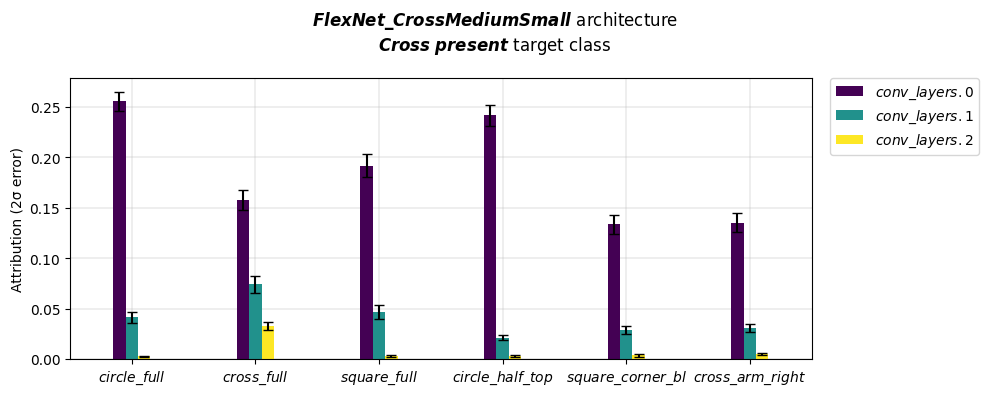

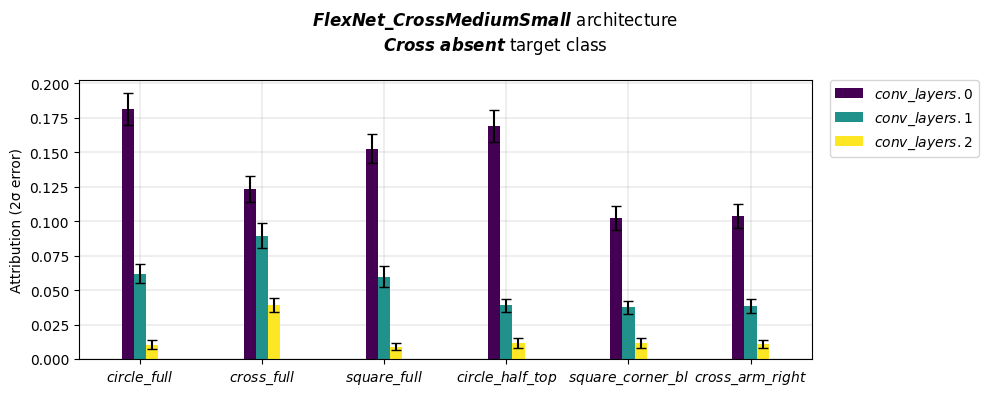

In [16]:
global_circle.plot()
global_no_circle.plot()

In [17]:
# --- Retrieve all conv layer names from the model ---
all_conv_layers = [name for name in vtcav_model.getLayerNames() if name.startswith('conv_layers.')]
print(f'Conv layers found: {all_conv_layers}\n')

local_clf = LocalVisualTCAV(
    test_image_filename=f'{img_with[0]:05d}.png',
    m_steps=50,
    model=vtcav_model,
    concept_images_dir=CONCEPTS_DIR,
    test_images_dir=TEST_IMAGES_DIR,
    random_images_folder='random_pool_4',
    cav_method='classifier',
    device=DEVICE,
)

local_clf.setConcepts(CONCEPTS)
local_clf.setLayers(all_conv_layers)

predictions_clf = local_clf.predict(no_sort=True)
local_clf.explain(cache_cav=False, cache_random=False)

# --- Print classifier-based CAVs per layer ---
print('=== Classifier-based CAVs ===')
for layer_name in all_conv_layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_clf.concepts:
        cav = local_clf.getCAVs(layer_name, concept_name)
        attribs = local_clf.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: accuracy={cav.accuracy:.3f}, attribs={attribs}')

# --- Print centroid-based CAVs per layer (from earlier explainer) ---
print('\n=== Centroid-based CAVs (from section 6) ===')
for layer_name in local_explainer.layers:
    print(f'\n--- {layer_name} ---')
    for concept_name in local_explainer.concepts:
        attribs = local_explainer.computations[layer_name][concept_name].attributions
        attribs = {k: v.item() if isinstance(v, torch.Tensor) else v for k, v in attribs.items()}
        print(f'  {concept_name}: attribs={attribs}')

Conv layers found: ['conv_layers.0', 'conv_layers.0.0', 'conv_layers.1', 'conv_layers.1.0', 'conv_layers.2', 'conv_layers.2.0']



Layers: 100%|██████████| 6/6 [00:05<00:00,  1.13it/s]

=== Classifier-based CAVs ===

--- conv_layers.0 ---
  circle_full: accuracy=1.000, attribs={0: 0.28801897168159485, 1: 0.040181964635849}
  cross_full: accuracy=1.000, attribs={0: 0.12140167504549026, 1: 0.021408744156360626}
  square_full: accuracy=1.000, attribs={0: 0.18412211537361145, 1: 0.03886459022760391}
  circle_half_top: accuracy=1.000, attribs={0: 0.2706895172595978, 1: 0.03180501610040665}
  square_corner_bl: accuracy=1.000, attribs={0: 0.1129385381937027, 1: 0.018938688561320305}
  cross_arm_right: accuracy=1.000, attribs={0: 0.1144840270280838, 1: 0.01985584944486618}

--- conv_layers.0.0 ---
  circle_full: accuracy=0.975, attribs={0: 0.00041835810407064855, 1: 0.0005708333337679505}
  cross_full: accuracy=0.980, attribs={0: 0.00032911726157180965, 1: 0.0004519810026977211}
  square_full: accuracy=0.970, attribs={0: 0.00048575899563729763, 1: 0.0006632835720665753}
  circle_half_top: accuracy=0.980, attribs={0: 0.0003418253909330815, 1: 0.00046754389768466353}
  square_c

In [18]:
# --- Compare centroid vs classifier CAV directions across all shared layers ---
shared_layers = [l for l in all_conv_layers if l in local_explainer.layers]

print('Cosine similarity between centroid and classifier CAV directions:')
for layer_name in shared_layers:
    print(f'\n--- {layer_name} ---')
    for cn in concept_names:
        d_centroid = local_explainer.getCAVs(layer_name, cn).direction   # shape: [C]
        d_classifier = local_clf.getCAVs(layer_name, cn).direction       # shape: [C]
        cos = F.cosine_similarity(
            d_centroid.unsqueeze(0),   # [1, C]
            d_classifier.unsqueeze(0)  # [1, C]
        ).item()
        print(f'  {cn}: {cos:.4f}')

Cosine similarity between centroid and classifier CAV directions:

--- conv_layers.0 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.1 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000

--- conv_layers.2 ---
  circle_full: 1.0000
  cross_full: 1.0000
  square_full: 1.0000
  circle_half_top: 1.0000
  square_corner_bl: 1.0000
  cross_arm_right: 1.0000
